## 1. Download the MNIST dataset and visualize some samples.

In [2]:
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor()
train_data = datasets.MNIST('data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('data', train=False, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

## 2. CNN Model definition

In [3]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()

        # 1 = Input channel (Grayscale)
        # 16 = Feature maps (Output channels)
        # 3 = Kernel size (3x3) - This is the size of the convolutional kernel
        # 1 = Stride (1x1) - This is to skip some pixels
        # 1 = Padding (1x1) - This is to avoid any border effect

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x))) # [64, 16, 14, 14]
        x = self.pool(self.relu(self.conv2(x))) # [64, 32, 7, 7]
        x = self.flatten(x) # [64, 32 * 7 * 7]
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

model = CNNModel()
print(model)

CNNModel(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 3. Train the CNN model

In [4]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
for epoch in range(num_epochs):
    total_loss = 0
    for images, labels in train_loader:
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        total_loss += loss.item()
    print(f"Epoch {epoch+1}, avg loss: {total_loss / len(train_loader):.4f}")

Epoch 1, avg loss: 0.2181
Epoch 2, avg loss: 0.0656
Epoch 3, avg loss: 0.0469
Epoch 4, avg loss: 0.0355
Epoch 5, avg loss: 0.0290


## 4. Evaluate the model on the test set

In [6]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        guesses = torch.argmax(outputs, dim=1)

        correct += (guesses == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 98.71%


## 5. Mistakes

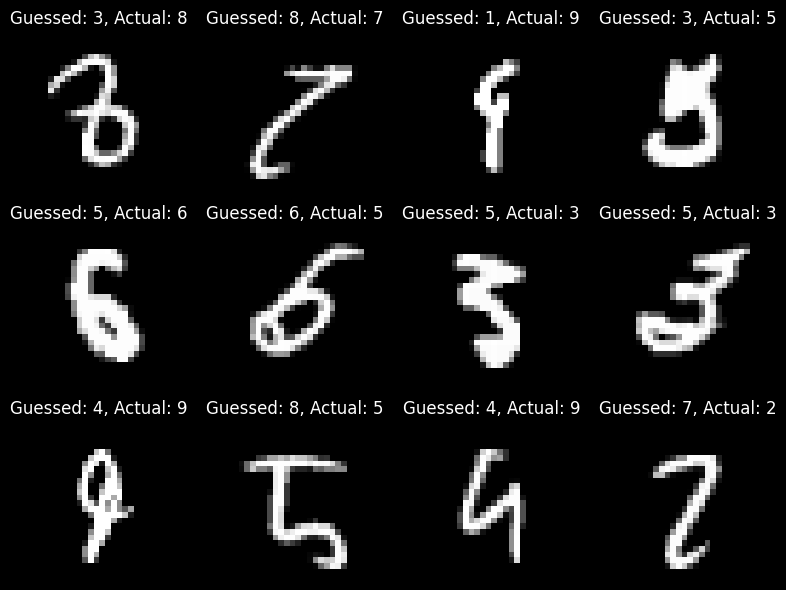

In [7]:
import matplotlib.pyplot as plt

wrong_images = []
wrong_guesses = []
wrong_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        predictions = model(images)
        guesses = predictions.argmax(dim=1)
        mistakes = guesses != labels
        wrong_images.extend(images[mistakes])
        wrong_guesses.extend(guesses[mistakes].tolist())
        wrong_labels.extend(labels[mistakes].tolist())
        if len(wrong_images) >= 12:
            break

fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(wrong_images[i][0], cmap="gray")
    ax.set_title(f"Guessed: {wrong_guesses[i]}, Actual: {wrong_labels[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Notes
- Above is a convolutional neural network (CNN) built for images
- Pixels -> edges -> shapes -> objects
- Validation flow
    - Train: learn from
    - Validation: see how well the model is doing on unseen data
    - Test: final evaluation of the model on unseen data